数据区间: 2014-01-02 ~ 2019-12-27
总交易天数: 1467
起始净值: 10000.00
最终净值: 9140.65
总收益率: -8.59%

📊 年度收益率统计:
 year  portfolio_return(%)  benchmark_return(%)  excess_return(%)  max_drawdown(%)  volatility(%)  sharpe_ratio  trading_days
 2014                 1.58                50.58            -49.01            -8.02          11.96          0.03           245
 2015                -1.96                 2.85             -4.81           -25.36          26.13         -0.02           244
 2016                -4.32                -4.37              0.04           -19.41          18.76         -0.62           245
 2017                 0.05                20.00            -19.95            -3.44           3.51         -0.54           245
 2018               -12.27               -25.75             13.48           -18.89          15.86         -0.89           245
 2019                19.08                32.74            -13.66            -5.81          10.64          1.38           243

📊 月度收益率统计:
year_month

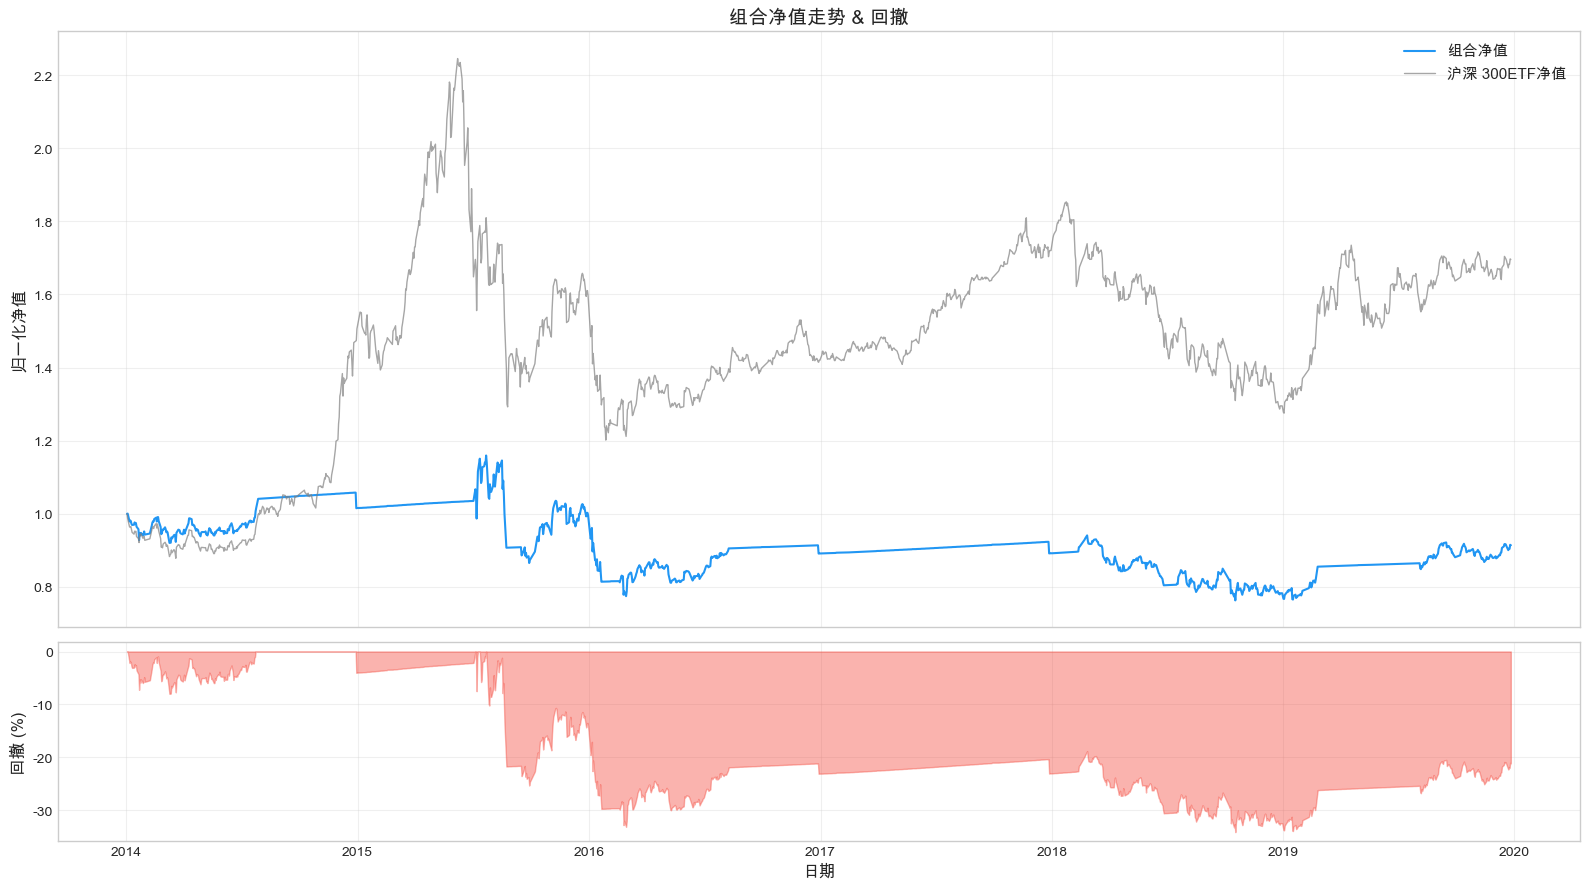

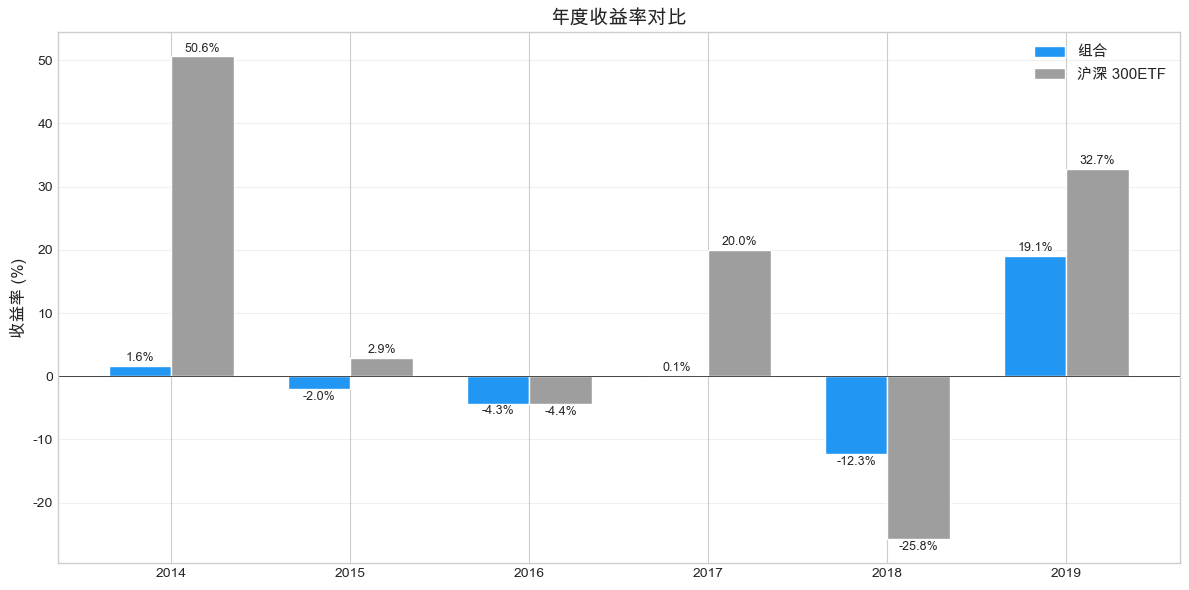

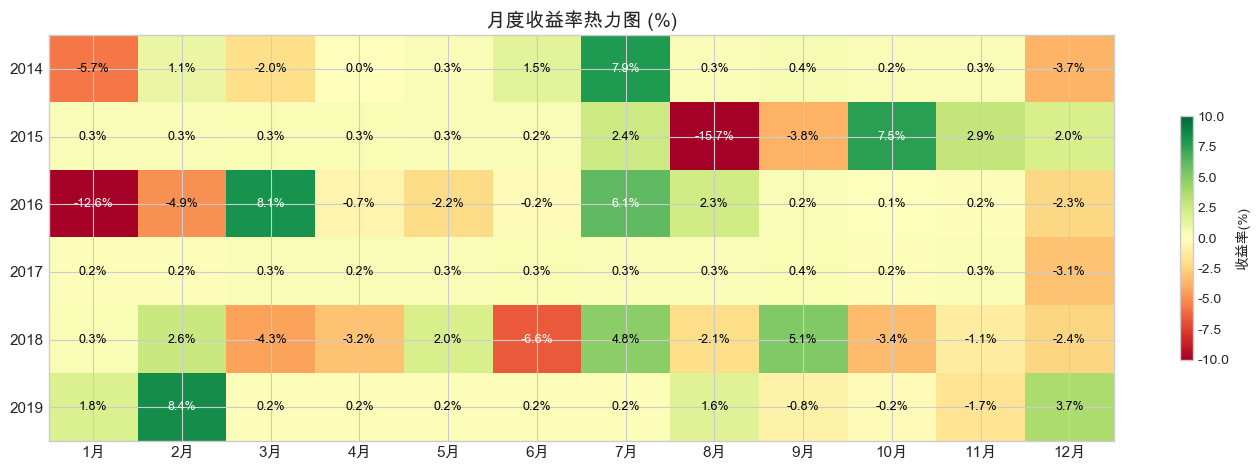

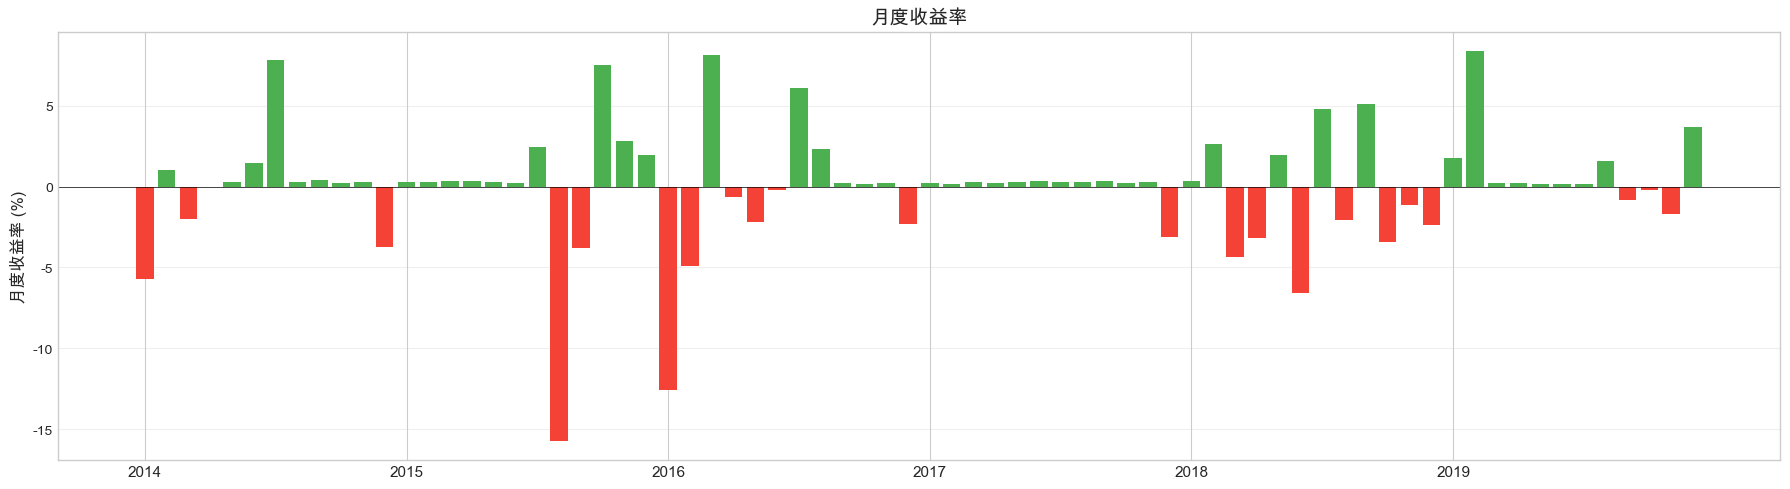

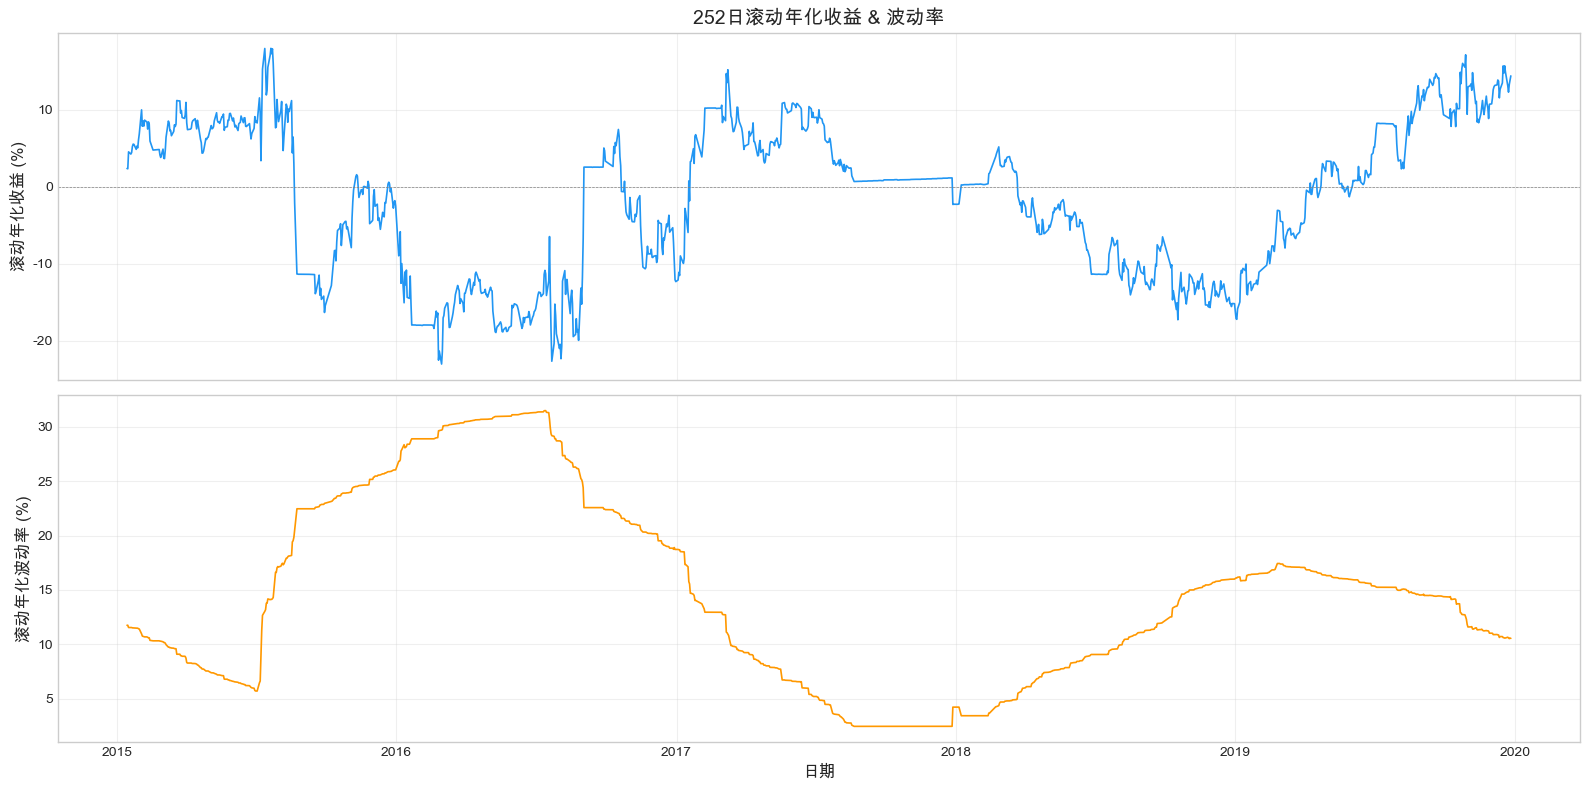

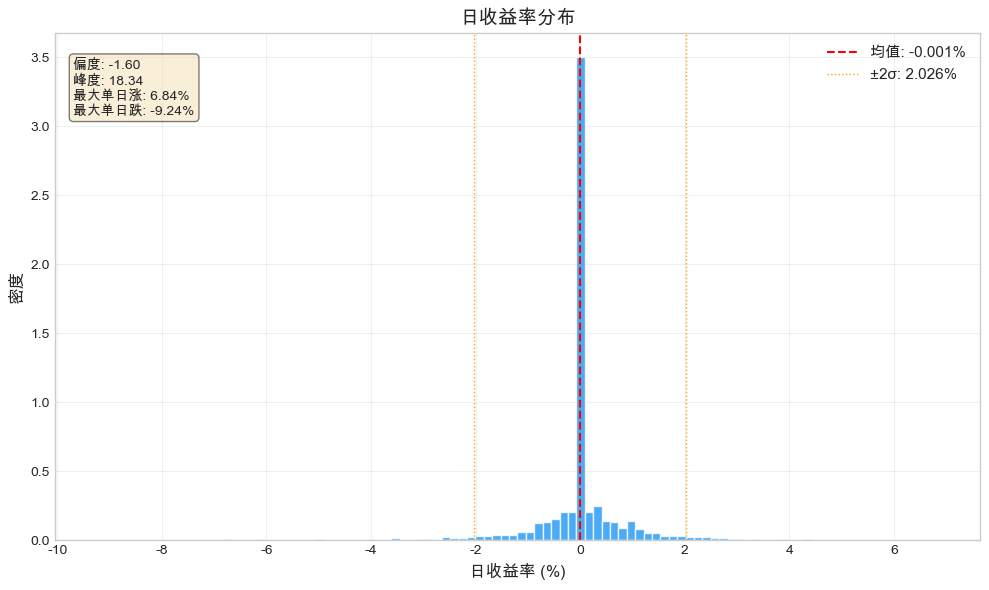

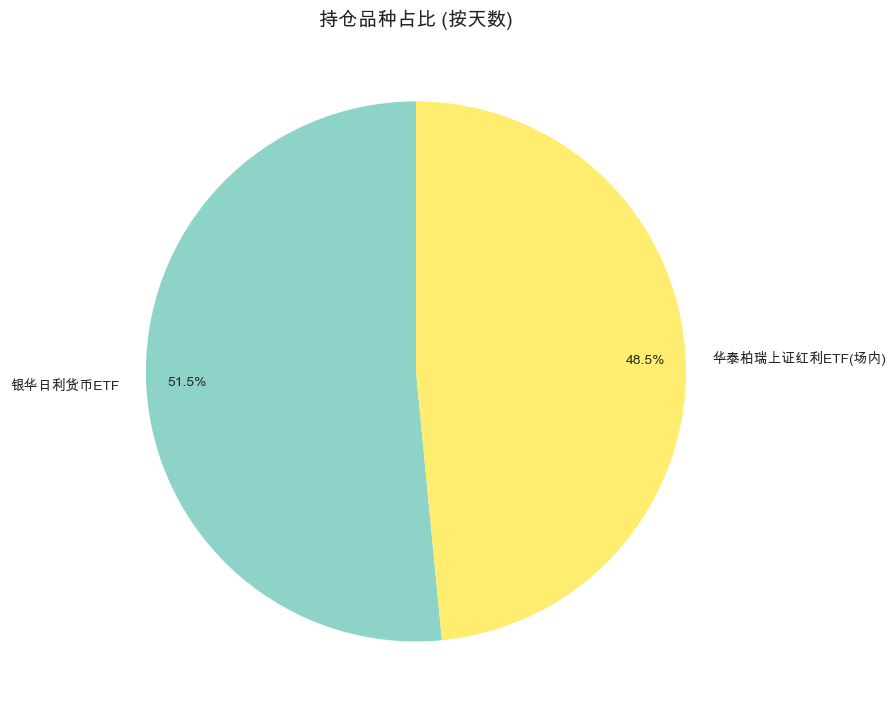

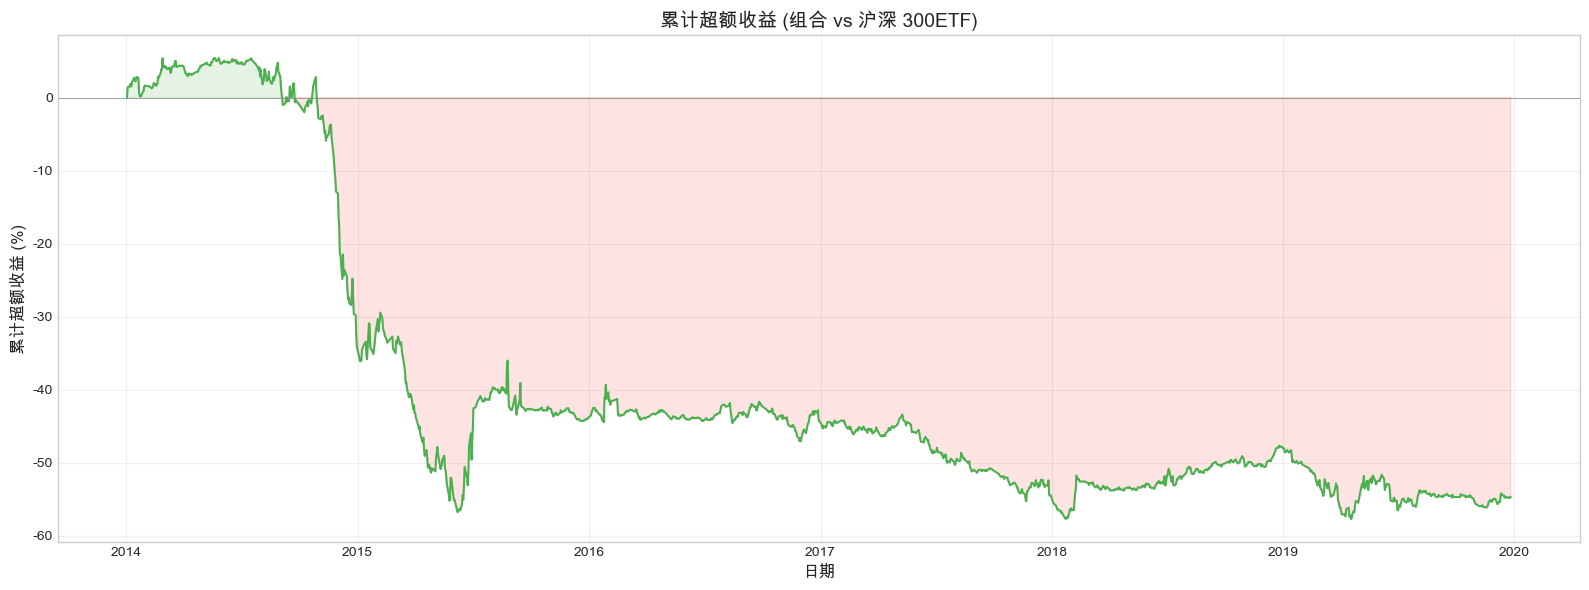

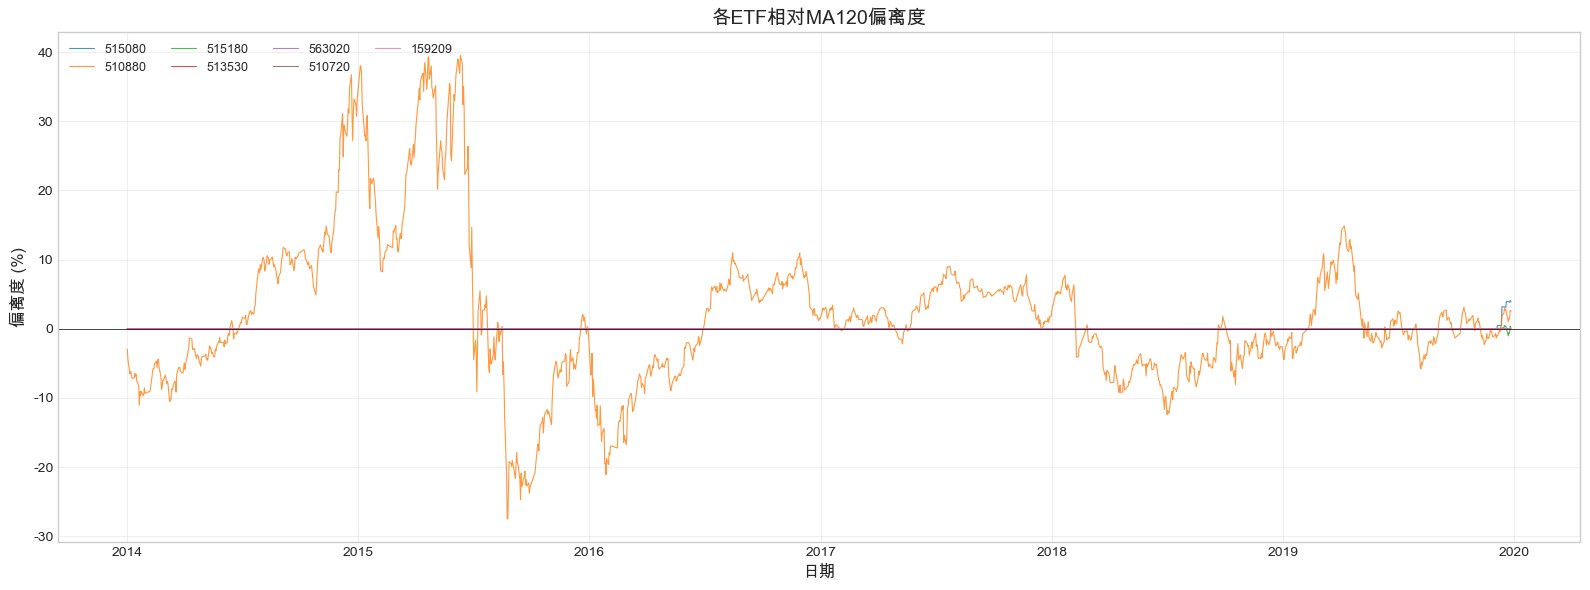

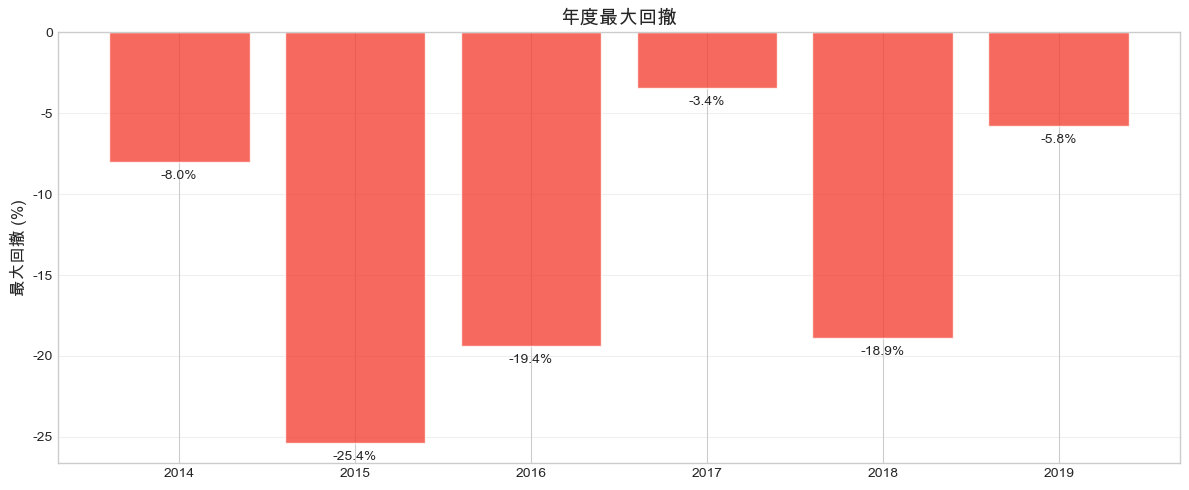


✅ 分析结果已保存到 portfolio_analysis.xlsx
✅ 所有图表已保存为PNG文件


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# 0. 设置中文字体 & 全局样式
# ============================================================
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# 1. 读取数据 & 基础处理
# ============================================================
df = pd.read_csv('fund_data/daily_status.csv', parse_dates=['date'])  # ← 改成你的文件名
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

# 组合日收益率
df['daily_return'] = df['portfolio_value'].pct_change()
# 沪深 300ETF日收益率
df['benchmark_daily_return'] = df['benchmark_close'].pct_change()

print("=" * 60)
print(f"数据区间: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"总交易天数: {len(df)}")
print(f"起始净值: {df['portfolio_value'].iloc[0]:.2f}")
print(f"最终净值: {df['portfolio_value'].iloc[-1]:.2f}")
print(f"总收益率: {(df['portfolio_value'].iloc[-1] / df['portfolio_value'].iloc[0] - 1) * 100:.2f}%")
print("=" * 60)

# ============================================================
# 2. 计算年度收益率
# ============================================================
def calc_yearly_returns(df):
    """计算每年的收益率（基于年初/年末净值）"""
    records = []
    for year, grp in df.groupby('year'):
        start_val = grp['portfolio_value'].iloc[0]
        end_val = grp['portfolio_value'].iloc[-1]
        ret = (end_val / start_val - 1) * 100
        
        # 沪深 300ETF
        bench_start = grp['benchmark_close'].iloc[0]
        bench_end = grp['benchmark_close'].iloc[-1]
        bench_ret = (bench_end / bench_start - 1) * 100
        
        # 最大回撤
        cummax = grp['portfolio_value'].cummax()
        drawdown = (grp['portfolio_value'] - cummax) / cummax
        max_dd = drawdown.min() * 100
        
        # 年化波动率
        vol = grp['daily_return'].std() * np.sqrt(252) * 100
        
        # 夏普比率(假设无风险利率2%)
        excess = grp['daily_return'].mean() - 0.02 / 252
        sharpe = excess / grp['daily_return'].std() * np.sqrt(252) if grp['daily_return'].std() > 0 else 0
        
        records.append({
            'year': year,
            'portfolio_return(%)': round(ret, 2),
            'benchmark_return(%)': round(bench_ret, 2),
            'excess_return(%)': round(ret - bench_ret, 2),
            'max_drawdown(%)': round(max_dd, 2),
            'volatility(%)': round(vol, 2),
            'sharpe_ratio': round(sharpe, 2),
            'trading_days': len(grp)
        })
    return pd.DataFrame(records)

yearly_df = calc_yearly_returns(df)
print("\n📊 年度收益率统计:")
print(yearly_df.to_string(index=False))

# ============================================================
# 3. 计算月度收益率
# ============================================================
def calc_monthly_returns(df):
    records = []
    for ym, grp in df.groupby('year_month'):
        start_val = grp['portfolio_value'].iloc[0]
        end_val = grp['portfolio_value'].iloc[-1]
        ret = (end_val / start_val - 1) * 100
        
        bench_start = grp['benchmark_close'].iloc[0]
        bench_end = grp['benchmark_close'].iloc[-1]
        bench_ret = (bench_end / bench_start - 1) * 100
        
        records.append({
            'year_month': str(ym),
            'year': ym.year,
            'month': ym.month,
            'portfolio_return(%)': round(ret, 2),
            'benchmark_return(%)': round(bench_ret, 2),
            'excess_return(%)': round(ret - bench_ret, 2),
        })
    return pd.DataFrame(records)

monthly_df = calc_monthly_returns(df)
print("\n📊 月度收益率统计:")
print(monthly_df.to_string(index=False))

# ============================================================
# 4. 持仓统计
# ============================================================
holding_stats = df.groupby('holding').agg(
    days=('holding', 'count'),
    avg_return=('daily_return', 'mean')
).reset_index()
holding_stats['avg_return(%)'] = (holding_stats['avg_return'] * 100).round(4)
holding_stats['proportion(%)'] = (holding_stats['days'] / len(df) * 100).round(2)
holding_stats.sort_values('days', ascending=False, inplace=True)

print("\n📊 持仓品种统计:")
print(holding_stats[['holding', 'days', 'proportion(%)', 'avg_return(%)']].to_string(index=False))

# ============================================================
# 5. 全局风险指标
# ============================================================
total_days = (df['date'].iloc[-1] - df['date'].iloc[0]).days
total_years = total_days / 365.25
total_return = df['portfolio_value'].iloc[-1] / df['portfolio_value'].iloc[0] - 1
annual_return = (1 + total_return) ** (1 / total_years) - 1

cummax = df['portfolio_value'].cummax()
drawdown = (df['portfolio_value'] - cummax) / cummax
max_dd = drawdown.min()
max_dd_end_idx = drawdown.idxmin()
max_dd_start_idx = df.loc[:max_dd_end_idx, 'portfolio_value'].idxmax()
max_dd_start_date = df.loc[max_dd_start_idx, 'date']
max_dd_end_date = df.loc[max_dd_end_idx, 'date']

annual_vol = df['daily_return'].std() * np.sqrt(252)
sharpe = (df['daily_return'].mean() - 0.02 / 252) / df['daily_return'].std() * np.sqrt(252)
calmar = annual_return / abs(max_dd) if max_dd != 0 else 0

# 胜率
win_days = (df['daily_return'] > 0).sum()
total_trade_days = df['daily_return'].notna().sum()
win_rate = win_days / total_trade_days * 100

print("\n" + "=" * 60)
print("📊 全局风险收益指标:")
print(f"  总收益率:       {total_return * 100:.2f}%")
print(f"  年化收益率:     {annual_return * 100:.2f}%")
print(f"  年化波动率:     {annual_vol * 100:.2f}%")
print(f"  夏普比率:       {sharpe:.2f}")
print(f"  卡尔玛比率:     {calmar:.2f}")
print(f"  最大回撤:       {max_dd * 100:.2f}%")
print(f"  最大回撤区间:   {max_dd_start_date.date()} ~ {max_dd_end_date.date()}")
print(f"  日胜率:         {win_rate:.1f}%")
print("=" * 60)


# ============================================================
# =====================  可视化部分  ==========================
# ============================================================

# ------ 图1: 净值曲线 + 回撤 ------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), height_ratios=[3, 1], sharex=True)

# 归一化
norm_port = df['portfolio_value'] / df['portfolio_value'].iloc[0]
norm_bench = df['benchmark_close'] / df['benchmark_close'].iloc[0]

ax1.plot(df['date'], norm_port, label='组合净值', linewidth=1.5, color='#2196F3')
ax1.plot(df['date'], norm_bench, label='沪深 300ETF净值', linewidth=1.0, color='gray', alpha=0.7)
ax1.set_ylabel('归一化净值', fontsize=12)
ax1.set_title('组合净值走势 & 回撤', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.fill_between(df['date'], drawdown * 100, 0, color='#F44336', alpha=0.4)
ax2.set_ylabel('回撤 (%)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_净值与回撤.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图2: 年度收益率对比柱状图 ------
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(yearly_df))
width = 0.35

bars1 = ax.bar(x - width / 2, yearly_df['portfolio_return(%)'], width,
               label='组合', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width / 2, yearly_df['benchmark_return(%)'], width,
               label='沪深 300ETF', color='#9E9E9E', edgecolor='white')

# 数值标注
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3 * np.sign(h),
            f'{h:.1f}%', ha='center', va='bottom' if h >= 0 else 'top', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3 * np.sign(h),
            f'{h:.1f}%', ha='center', va='bottom' if h >= 0 else 'top', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(yearly_df['year'].astype(str))
ax.set_ylabel('收益率 (%)', fontsize=12)
ax.set_title('年度收益率对比', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_年度收益对比.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图3: 月度收益率热力图 ------
years = sorted(monthly_df['year'].unique())
months = range(1, 13)
heatmap_data = monthly_df.pivot_table(index='year', columns='month',
                                       values='portfolio_return(%)', aggfunc='first')
heatmap_data = heatmap_data.reindex(index=years, columns=months)

fig, ax = plt.subplots(figsize=(14, max(4, len(years) * 0.8)))

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=-10, vmax=10)

ax.set_xticks(range(12))
ax.set_xticklabels([f'{m}月' for m in months], fontsize=11)
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=11)

# 标注数值
for i in range(len(years)):
    for j in range(12):
        val = heatmap_data.iloc[i, j]
        if pd.notna(val):
            color = 'white' if abs(val) > 6 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_title('月度收益率热力图 (%)', fontsize=14, fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.6, label='收益率(%)')

plt.tight_layout()
plt.savefig('03_月度收益热力图.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图4: 月度收益率柱状图(按时间排列) ------
fig, ax = plt.subplots(figsize=(18, 5))

colors = ['#4CAF50' if r >= 0 else '#F44336' for r in monthly_df['portfolio_return(%)']]
ax.bar(range(len(monthly_df)), monthly_df['portfolio_return(%)'], color=colors, edgecolor='none')

# 每年第一个月标注年份
tick_positions = []
tick_labels = []
for i, row in monthly_df.iterrows():
    if row['month'] == 1:
        tick_positions.append(i)
        tick_labels.append(str(row['year']))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=11)
ax.set_ylabel('月度收益率 (%)', fontsize=12)
ax.set_title('月度收益率', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_月度收益柱状图.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图5: 滚动年化收益 & 滚动波动率 (252日窗口) ------
if len(df) > 252:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    rolling_ret = df['daily_return'].rolling(252).mean() * 252 * 100
    rolling_vol = df['daily_return'].rolling(252).std() * np.sqrt(252) * 100
    rolling_sharpe = (df['daily_return'].rolling(252).mean() - 0.02 / 252) / \
                     df['daily_return'].rolling(252).std() * np.sqrt(252)

    ax1.plot(df['date'], rolling_ret, color='#2196F3', linewidth=1.2)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax1.set_ylabel('滚动年化收益 (%)', fontsize=12)
    ax1.set_title('252日滚动年化收益 & 波动率', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(df['date'], rolling_vol, color='#FF9800', linewidth=1.2)
    ax2.set_ylabel('滚动年化波动率 (%)', fontsize=12)
    ax2.set_xlabel('日期', fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('05_滚动收益波动率.png', dpi=150, bbox_inches='tight')
    plt.show()


# ------ 图6: 日收益率分布直方图 ------
fig, ax = plt.subplots(figsize=(10, 6))

returns = df['daily_return'].dropna() * 100
ax.hist(returns, bins=100, color='#2196F3', edgecolor='white', alpha=0.8, density=True)

mean_r = returns.mean()
std_r = returns.std()
ax.axvline(mean_r, color='red', linestyle='--', linewidth=1.5, label=f'均值: {mean_r:.3f}%')
ax.axvline(mean_r + 2 * std_r, color='orange', linestyle=':', linewidth=1, label=f'±2σ: {2 * std_r:.3f}%')
ax.axvline(mean_r - 2 * std_r, color='orange', linestyle=':', linewidth=1)

ax.set_xlabel('日收益率 (%)', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('日收益率分布', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 添加统计信息文本框
textstr = f'偏度: {returns.skew():.2f}\n峰度: {returns.kurtosis():.2f}\n最大单日涨: {returns.max():.2f}%\n最大单日跌: {returns.min():.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('06_日收益分布.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图7: 持仓占比饼图 ------
fig, ax = plt.subplots(figsize=(9, 9))

top_n = holding_stats.head(8)
if len(holding_stats) > 8:
    other = pd.DataFrame({
        'holding': ['其他'],
        'days': [holding_stats.iloc[8:]['days'].sum()]
    })
    top_n = pd.concat([top_n, other], ignore_index=True)

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(top_n)))
wedges, texts, autotexts = ax.pie(
    top_n['days'], labels=top_n['holding'], autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.85
)
ax.set_title('持仓品种占比 (按天数)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('07_持仓占比.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图8: 超额收益累计曲线 ------
fig, ax = plt.subplots(figsize=(16, 6))

df['excess_daily'] = df['daily_return'] - df['benchmark_daily_return']
df['cum_excess'] = (1 + df['excess_daily'].fillna(0)).cumprod()
cum_excess_pct = (df['cum_excess'] - 1) * 100

ax.plot(df['date'], cum_excess_pct, color='#4CAF50', linewidth=1.5)
ax.fill_between(df['date'], cum_excess_pct, 0,
                where=cum_excess_pct >= 0, color='#4CAF50', alpha=0.15)
ax.fill_between(df['date'], cum_excess_pct, 0,
                where=cum_excess_pct < 0, color='#F44336', alpha=0.15)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('累计超额收益 (%)', fontsize=12)
ax.set_xlabel('日期', fontsize=12)
ax.set_title('累计超额收益 (组合 vs 沪深 300ETF)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_累计超额收益.png', dpi=150, bbox_inches='tight')
plt.show()


# ------ 图9: 各ETF偏离度走势 ------
deviation_cols = [c for c in df.columns if c.startswith('deviation_')]
if deviation_cols:
    fig, ax = plt.subplots(figsize=(16, 6))
    for col in deviation_cols:
        etf_code = col.replace('deviation_', '')
        ax.plot(df['date'], df[col] * 100, label=etf_code, linewidth=0.8, alpha=0.8)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('偏离度 (%)', fontsize=12)
    ax.set_xlabel('日期', fontsize=12)
    ax.set_title('各ETF相对MA120偏离度', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, ncol=4, loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('09_ETF偏离度.png', dpi=150, bbox_inches='tight')
    plt.show()


# ------ 图10: 年度最大回撤柱状图 ------
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(yearly_df['year'].astype(str), yearly_df['max_drawdown(%)'],
       color='#F44336', edgecolor='white', alpha=0.8)

for i, v in enumerate(yearly_df['max_drawdown(%)']):
    ax.text(i, v - 0.5, f'{v:.1f}%', ha='center', va='top', fontsize=10, fontweight='bold')

ax.set_ylabel('最大回撤 (%)', fontsize=12)
ax.set_title('年度最大回撤', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('10_年度最大回撤.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 11. 导出结果到 Excel
# ============================================================
with pd.ExcelWriter('portfolio_analysis.xlsx', engine='openpyxl') as writer:
    yearly_df.to_excel(writer, sheet_name='年度统计', index=False)
    monthly_df.to_excel(writer, sheet_name='月度统计', index=False)
    holding_stats[['holding', 'days', 'proportion(%)', 'avg_return(%)']].to_excel(
        writer, sheet_name='持仓统计', index=False)

print("\n✅ 分析结果已保存到 portfolio_analysis.xlsx")
print("✅ 所有图表已保存为PNG文件")